In [6]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel
import boto3
from google.cloud import storage
import torch

model_storage_folder = 'downloaded_models'

bucket_name = 'downloaded_llms'
model_list = ["google_gemma-2b-it", "meta-llama_Llama-2-7b-chat-hf", "openai-community_gpt2", "facebook_opt-2.7b", "facebook_opt-125m"]



In [1]:
def load_model_from_path(model_name, bucket_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    model_files = [blob.name for blob in blobs if not blob.name.endswith('/')]
    return AutoModel.from_pretrained(model_files)

In [2]:
def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    os.makedirs(local_path, exist_ok=True)

    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path): 
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")


def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path


In [4]:
import shutil

def count_layers(model):
    layer_names = ['BertLayer', 'GPT2Block', 'T5Block', 'EncoderLayer', 'DecoderLayer', 'TransformerBlock']
    num_hidden_layers = 0
    for _, module in model.named_modules():
        if any(layer_name in module.__class__.__name__ for layer_name in layer_names):
            num_hidden_layers += 1

    return num_hidden_layers

def get_model_size(model_name, bucket_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/"
    blobs = bucket.list_blobs(prefix=prefix)
    total_size = sum(blob.size for blob in blobs)
    return total_size / (1024 * 1024)


def analyze_model_parameters(model):
    try:
        model_params = {name: param for name, param in model.named_parameters()}
        all_params = np.concatenate([p.data.cpu().numpy().flatten() for p in model_params.values()])
        
        stats = {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'total_layers': len(list(model.parameters())),
            'min': np.min(all_params),
            'max': np.max(all_params),
            'percent_within_1_std': np.mean((all_params >= -1) & (all_params <= 1)) * 100
        }
        return stats
    except Exception as e:
        print(f"Error during analysis: {e}")
        return {'error': str(e)}
    finally:
        gc.collect()

def analyze_model_stats(model, model_name, bucket_name):
    try:
        param_stats= analyze_model_parameters(model)
        num_hidden_layers = count_layers(model)
        model_size_mb = get_model_size(model_name, bucket_name)
        
        stats = {
            'model_size_mb': model_size_mb,
            'num_hidden_layers': num_hidden_layers,
            **param_stats
        }
        return stats
    except Exception as e:
        print(f"Error during analysis of {model_name}: {e}")
        return {'error': str(e)} 

def cleanup_model_directory(local_path):
    shutil.rmtree(local_path)
    print(f"Deleted model files at {local_path}")
    
def update_histogram_incrementally(model, bin_edges, bin_counts):
    for param in model.parameters():
        flat_param = param.data.cpu().numpy().flatten()
        counts, _ = np.histogram(flat_param, bins=bin_edges)
        bin_counts += counts
    return bin_counts

def analyze_model_data_types(model):
    data_types_stats = {}
    total_size_bytes = 0

    for param in model.parameters():
        param_size_bytes = param.data.element_size() * param.data.nelement()
        total_size_bytes += param_size_bytes
        data_type = str(param.dtype)

        if data_type not in data_types_stats:
            data_types_stats[data_type] = {'count': 0, 'total_size_bytes': 0, 'total_elements': 0}
        
        data_types_stats[data_type]['count'] += 1
        data_types_stats[data_type]['total_size_bytes'] += param_size_bytes
        data_types_stats[data_type]['total_elements'] += param.data.nelement()

    for data_type, stats in data_types_stats.items():
        stats['total_size_gb'] = stats['total_size_bytes'] / (1024**3)
        stats['percent_total_size'] = (stats['total_size_bytes'] / total_size_bytes) * 100
        stats['avg_elements'] = stats['total_elements'] / stats['count']
        stats['avg_size_mb'] = (stats['total_size_bytes'] / (1024**2)) / stats['count']

    return data_types_stats

In [5]:
# main workflow
def collect_model_stats(model_list, bucket_name, bin_edges):
    bin_counts = np.zeros(len(bin_edges) - 1, dtype=int)
    model_stats = []
    all_data_types_stats = []
    for model_name in model_list:
        print(f"Starting model analysis for {model_name}...")
        
        model, local_path = load_model_from_path(model_name, bucket_name)
        stats = analyze_model_stats(model, model_name, bucket_name)
        stats['model_name'] = model_name
        model_stats.append(stats)
        
        bin_counts = update_histogram_incrementally(model, bin_edges, bin_counts)
        
        data_types_stats = analyze_model_data_types(model)
        all_data_types_stats.append({'model_name': model_name, 'data_types_stats': data_types_stats})
        
        cleanup_model_directory(local_path)
        gc.collect()
        
        print(f"Completed model analysis for {model_name}.")
    
    data_list = [
        {
            'Layer Type': dtype,
            'Count': stats['count'],
            'Total Sz in GB': f"{stats['total_size_gb']:.2f} ({stats['percent_total_size']:.2f}%)",
            'Avg Para #': int(stats['avg_elements']),
            'Avg Sz in MB': f"{stats['avg_size_mb']:.2f}"
        }
        for model_stat in all_data_types_stats
        for dtype, stats in model_stat['data_types_stats'].items()
    ]
    df_stats = pd.DataFrame(data_list)
    return pd.DataFrame(model_stats), bin_counts, df_stats


In [7]:
model_list = ["google_gemma-2b-it", "meta-llama_Llama-2-7b-chat-hf", "openai-community_gpt2", "facebook_opt-2.7b", "facebook_opt-125m"]

bin_edges = np.linspace(-3, 3, num=30)
model_statistics, bin_counts, df_stats = collect_model_stats(model_list, bucket_name, bin_edges)


Starting model analysis for google_gemma-2b-it...
Downloaded google_gemma-2b-it/config.json to ./google_gemma-2b-it/config.json.
Downloaded google_gemma-2b-it/pytorch_model.bin to ./google_gemma-2b-it/pytorch_model.bin.


/opt/conda/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Deleted model files at ./google_gemma-2b-it
Completed model analysis for google_gemma-2b-it.
Starting model analysis for meta-llama_Llama-2-7b-chat-hf...
Downloaded meta-llama_Llama-2-7b-chat-hf/config.json to ./meta-llama_Llama-2-7b-chat-hf/config.json.
Downloaded meta-llama_Llama-2-7b-chat-hf/pytorch_model.bin to ./meta-llama_Llama-2-7b-chat-hf/pytorch_model.bin.
Deleted model files at ./meta-llama_Llama-2-7b-chat-hf
Completed model analysis for meta-llama_Llama-2-7b-chat-hf.
Starting model analysis for openai-community_gpt2...
Downloaded openai-community_gpt2/config.json to ./openai-community_gpt2/config.json.
Downloaded openai-community_gpt2/pytorch_model.bin to ./openai-community_gpt2/pytorch_model.bin.
Deleted model files at ./openai-community_gpt2
Completed model analysis for openai-community_gpt2.
Starting model analysis for facebook_opt-2.7b...
Downloaded facebook_opt-2.7b/config.json to ./facebook_opt-2.7b/config.json.
Downloaded facebook_opt-2.7b/pytorch_model.bin to ./faceb

In [19]:
print(model_statistics)

   model_size_mb  num_hidden_layers  total_parameters        min        max  \
0    9560.352129                 18        2506172416  -9.750000  14.312500   
1   25205.144488                 32        6607343616  -1.414062   2.843750   
2     474.749109                 12         124439808 -11.050447  17.419317   
3   10115.219238                 32        2651596800  -0.500000   1.000000   
4     477.817388                 12         125239296  -1.231445   1.560547   

   percent_within_1_std                     model_name  total_layers  
0             99.947758             google_gemma-2b-it           164  
1             99.999937  meta-llama_Llama-2-7b-chat-hf           290  
2             99.988236          openai-community_gpt2           148  
3            100.000000              facebook_opt-2.7b           516  
4             99.999347              facebook_opt-125m           196  


In [9]:
print(df_stats)

      Layer Type  Count   Total Sz in GB  Avg Para # Avg Sz in MB
0  torch.float32    164   9.34 (100.00%)    15281539        58.29
1  torch.float32    290  24.61 (100.00%)    22783943        86.91
2  torch.float32    148   0.46 (100.00%)      840809         3.21
3  torch.float32    516   9.88 (100.00%)     5138753        19.60
4  torch.float32    196   0.47 (100.00%)      638976         2.44


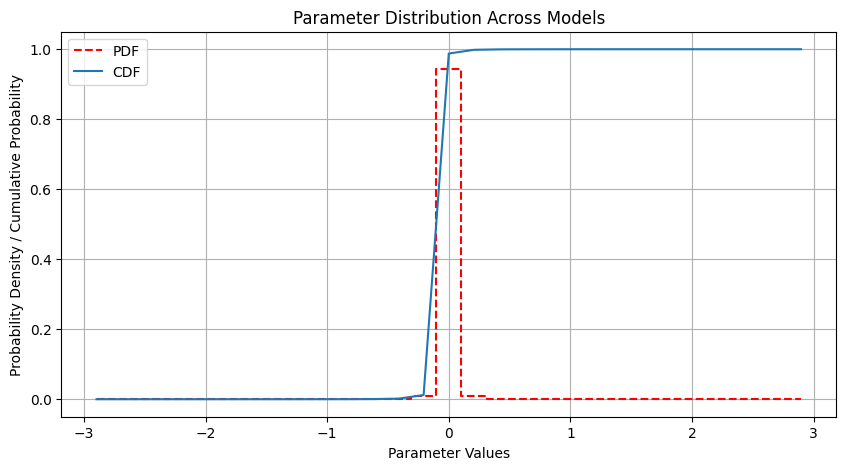

In [10]:
pdf = bin_counts / (np.sum(bin_counts) * np.diff(bin_edges)) / 5
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

cdf = np.cumsum(pdf * np.diff(bin_edges)) * 5


plt.figure(figsize=(10, 5))
plt.plot(bin_centers, pdf, drawstyle='steps-mid', linestyle='--', color='red', label='PDF')
plt.plot(bin_centers, cdf, label='CDF')
plt.xlabel('Parameter Values')
plt.ylabel('Probability Density / Cumulative Probability')
plt.title('Parameter Distribution Across Models')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [11]:
def calculate_cdf(data):
    data_sorted = np.sort(data)
    cdf = np.arange(1, len(data_sorted) + 1) / float(len(data_sorted))
    return data_sorted, cdf

size_sorted, size_cdf = calculate_cdf(model_statistics['model_size_mb'])
params_sorted, params_cdf = calculate_cdf(model_statistics['total_parameters'])
layers_sorted, layers_cdf = calculate_cdf(model_statistics['num_hidden_layers'])

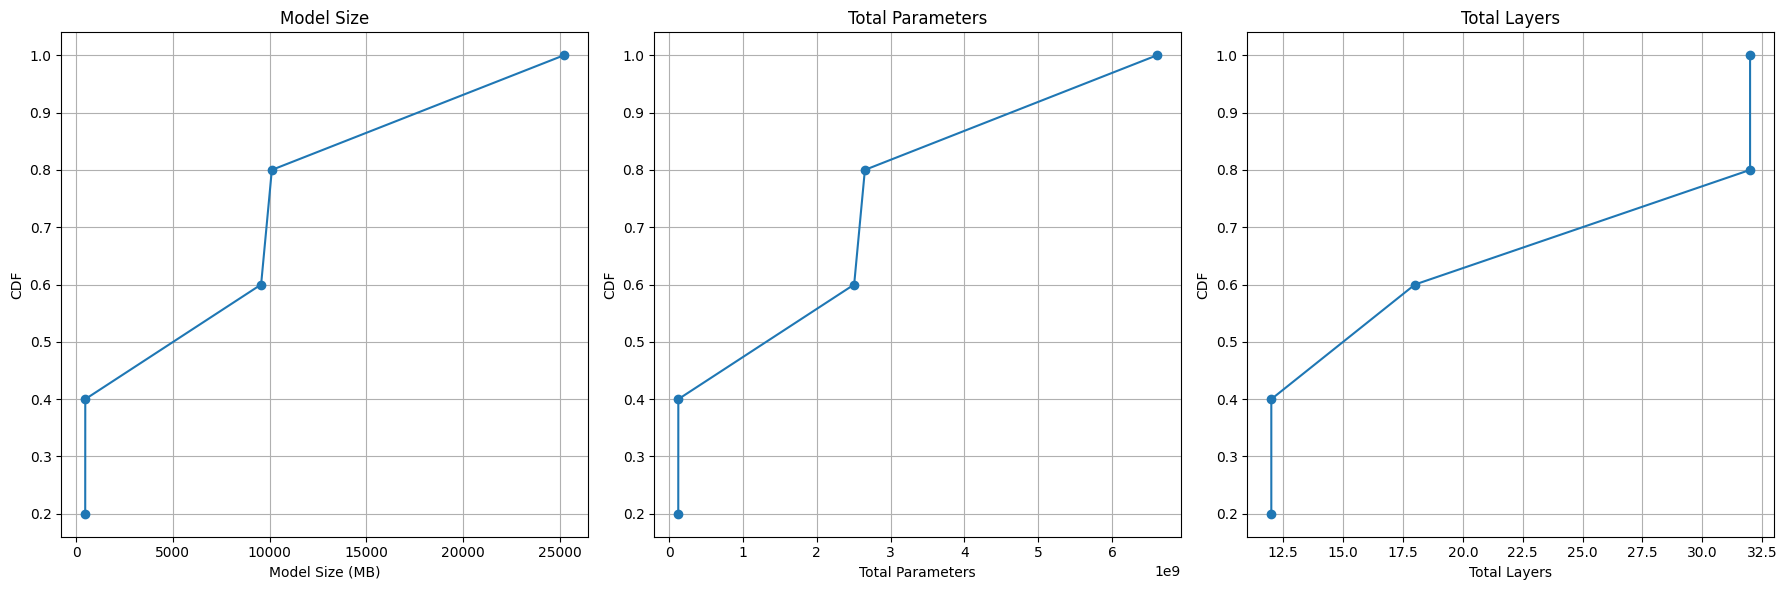

In [12]:
plt.figure(figsize=(18, 6))

# model size in MB
plt.subplot(1, 3, 1)
plt.plot(size_sorted, size_cdf, marker='o')
plt.xlabel('Model Size (MB)')
plt.ylabel('CDF')
plt.title('Model Size')
plt.grid(True)

# number of parameters
plt.subplot(1, 3, 2)
plt.plot(params_sorted, params_cdf, marker='o')
plt.xlabel('Total Parameters')
plt.ylabel('CDF')
plt.title('Total Parameters')
plt.grid(True)

# layer count
plt.subplot(1, 3, 3)
plt.plot(layers_sorted, layers_cdf, marker='o')
plt.xlabel('Total Layers')
plt.ylabel('CDF')
plt.title('Total Layers')
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import transformers
print(transformers.__version__)


4.40.2


In [8]:
import os
import torch
import math
from collections import Counter, defaultdict
from google.cloud import storage
from transformers import AutoModel
from pathlib import Path
from tqdm import tqdm

def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    Path(local_path).mkdir(parents=True, exist_ok=True)
    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path):
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")

def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path

def analyze_exponents_and_mantissas(model):
    exponent_counts = Counter()
    mantissa_counts = defaultdict(int)
    total_params = sum(p.numel() for p in model.parameters() if p.dtype == torch.float32)
    pbar = tqdm(total=total_params, desc="Analyzing exponent and mantissa")
    for param in model.parameters():
        if param.dtype == torch.float32:
            param_data = param.data.cpu().numpy().flatten()
            for data in param_data:
                mantissa, exponent = math.frexp(data)
                exponent_bin = f"{exponent + 127:08b}" 
                mantissa_bin = f"{int((mantissa * 2) * (2**23)):023b}"  
                exponent_counts[exponent_bin] += 1
                mantissa_counts[mantissa_bin] += 1
                pbar.update(1)
    pbar.close()

    return exponent_counts, mantissa_counts

def print_distribution(counts, description):
    total_counts = sum(counts.values())
    print(f"\nDistribution of {description}:")
    cnt = 0
    for key, count in sorted(counts.items(), key=lambda item: item[1], reverse=True):
        percentage = (count / total_counts) * 100
        print(f"{key}: {percentage:.2f}% ({count} times)")
        cnt += 1
        if cnt == 50:
            break

def cleanup_directory(path):
    for root, dirs, files in os.walk(path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
    os.rmdir(path)

In [6]:

model_list = ["facebook_opt-125m"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    exponent_counts, mantissa_counts = analyze_exponents_and_mantissas(model)
    print_distribution(exponent_counts, 'Exponents in Binary')
    print_distribution(mantissa_counts, 'Mantissas in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")


Starting analysis for facebook_opt-125m...
Downloaded facebook_opt-125m/config.json to ./facebook_opt-125m/config.json.
Downloaded facebook_opt-125m/pytorch_model.bin to ./facebook_opt-125m/pytorch_model.bin.


Analyzing exponent and mantissa: 100%|██████████| 125239296/125239296 [04:11<00:00, 496986.32it/s]



Distribution of Exponents in Binary:
01111010: 24.20% (30309193 times)
01111011: 23.23% (29090834 times)
01111001: 17.07% (21382406 times)
01111100: 12.63% (15821842 times)
01111000: 10.00% (12520906 times)
01110111: 5.34% (6691239 times)
01110110: 2.75% (3448384 times)
01111101: 1.89% (2361437 times)
01110101: 1.40% (1754677 times)
01110100: 0.71% (885923 times)
01110011: 0.35% (444330 times)
01110010: 0.18% (221525 times)
01110001: 0.09% (110799 times)
01111110: 0.06% (73663 times)
01110000: 0.04% (55522 times)
01101111: 0.02% (27995 times)
01101110: 0.01% (14073 times)
01111111: 0.01% (9225 times)
01101101: 0.01% (7009 times)
01101100: 0.00% (3473 times)
01101011: 0.00% (1746 times)
10000000: 0.00% (1557 times)
01101010: 0.00% (887 times)
01101001: 0.00% (441 times)
01101000: 0.00% (210 times)

Distribution of Mantissas in Binary:
100000000010000000000000: 0.11% (136144 times)
100000000100000000000000: 0.10% (128409 times)
100000000110000000000000: 0.10% (123931 times)
100000001000

In [7]:
model_list = ["openai-community_gpt2"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    exponent_counts, mantissa_counts = analyze_exponents_and_mantissas(model)
    print_distribution(exponent_counts, 'Exponents in Binary')
    print_distribution(mantissa_counts, 'Mantissas in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for openai-community_gpt2...
Downloaded openai-community_gpt2/config.json to ./openai-community_gpt2/config.json.
Downloaded openai-community_gpt2/pytorch_model.bin to ./openai-community_gpt2/pytorch_model.bin.


Analyzing exponent and mantissa: 100%|██████████| 124439808/124439808 [05:55<00:00, 349742.32it/s]



Distribution of Exponents in Binary:
01111100: 28.39% (35331519 times)
01111101: 24.99% (31092262 times)
01111011: 18.71% (23277216 times)
01111010: 10.24% (12740393 times)
01111110: 6.18% (7693754 times)
01111001: 5.33% (6631103 times)
01111000: 2.81% (3500716 times)
01110111: 1.51% (1883309 times)
01110110: 0.79% (981770 times)
01110101: 0.40% (498074 times)
01111111: 0.24% (294684 times)
01110100: 0.20% (250298 times)
01110011: 0.10% (125657 times)
01110010: 0.05% (62190 times)
01110001: 0.03% (31170 times)
01110000: 0.01% (15386 times)
10000000: 0.01% (13194 times)
01101111: 0.01% (7834 times)
01101110: 0.00% (3848 times)
01101101: 0.00% (1976 times)
10000001: 0.00% (1251 times)
01101100: 0.00% (1010 times)
01101011: 0.00% (478 times)
01101010: 0.00% (257 times)
10000010: 0.00% (157 times)
01101001: 0.00% (123 times)
01101000: 0.00% (66 times)
10000011: 0.00% (34 times)
01100111: 0.00% (33 times)
01100110: 0.00% (19 times)
01100101: 0.00% (14 times)
01100100: 0.00% (6 times)
01100

In [132]:
import os
import torch
import math
from collections import Counter, defaultdict
from google.cloud import storage
from transformers import AutoModel
from pathlib import Path
from tqdm import tqdm

def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    Path(local_path).mkdir(parents=True, exist_ok=True)
    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path):
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")

def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path

def analyze_byte_by_byte(model):
    byte_counts = Counter()

    total_params = sum(p.numel() for p in model.parameters() if p.dtype in [torch.float32, torch.float16])
    pbar = tqdm(total=total_params, desc="Analyzing bytes")

    for param in model.parameters():
        param_data = param.data.cpu().numpy() 

        for data in param_data.flatten():
            weight_bytes = data.tobytes()
            for b in weight_bytes:
                byte_counts[f'{b:02x}'] += 1
            pbar.update(1)

    pbar.close()
    return byte_counts

def print_distribution(counts, description, limit=50):
    total_counts = sum(counts.values())
    print(f"\nDistribution of {description}:")
    sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    for key, count in sorted_counts[:limit]:  
        percentage = (count / total_counts) * 100
        print(f"{key.upper()}: {percentage:.2f}% ({count} times)")


def cleanup_directory(path):
    for root, dirs, files in os.walk(path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
    os.rmdir(path)

In [24]:

model_list = ["facebook_opt-125m"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_byte_by_byte(model)
    print_distribution(byte_counts, 'Bytes in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for facebook_opt-125m...


Analyzing bytes: 100%|██████████| 125239296/125239296 [06:50<00:00, 305002.35it/s]



Distribution of Bytes in Binary:
00: 28.31% (141812103 times)
3D: 5.62% (28136916 times)
3C: 5.40% (27065209 times)
BC: 5.11% (25580386 times)
BD: 3.54% (17726056 times)
80: 3.31% (16577015 times)
20: 3.24% (16225928 times)
40: 3.23% (16168645 times)
A0: 3.22% (16148584 times)
C0: 3.21% (16103330 times)
60: 3.20% (16023478 times)
E0: 3.19% (15958248 times)
3B: 2.02% (10107627 times)
BB: 2.01% (10062977 times)
BA: 0.62% (3087808 times)
3A: 0.61% (3078322 times)
3E: 0.45% (2254656 times)
B9: 0.23% (1155478 times)
39: 0.23% (1143751 times)
BE: 0.22% (1124110 times)
81: 0.16% (810919 times)
82: 0.15% (767526 times)
83: 0.15% (742307 times)
01: 0.15% (740519 times)
84: 0.14% (720162 times)
02: 0.14% (711284 times)
85: 0.14% (706582 times)
86: 0.14% (695284 times)
03: 0.14% (695187 times)
04: 0.14% (683136 times)
87: 0.14% (683035 times)
88: 0.14% (676632 times)
05: 0.13% (671116 times)
89: 0.13% (668306 times)
06: 0.13% (663901 times)
8A: 0.13% (662121 times)
B8: 0.13% (660050 times)
07: 0

In [25]:

model_list = ["openai-community_gpt2"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_byte_by_byte(model)
    print_distribution(byte_counts, 'Bytes in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for openai-community_gpt2...


Analyzing bytes: 100%|██████████| 124439808/124439808 [06:53<00:00, 301143.79it/s]



Distribution of Bytes in Binary:
BD: 6.18% (30785469 times)
3D: 6.17% (30709826 times)
BE: 4.20% (20900980 times)
3E: 4.17% (20773099 times)
3C: 2.24% (11139938 times)
BC: 2.23% (11120051 times)
3B: 0.84% (4156541 times)
BB: 0.83% (4120052 times)
3A: 0.44% (2207681 times)
BA: 0.44% (2169190 times)
80: 0.35% (1735551 times)
83: 0.34% (1691328 times)
81: 0.34% (1688505 times)
82: 0.34% (1686010 times)
00: 0.34% (1676563 times)
01: 0.34% (1668253 times)
02: 0.33% (1663934 times)
39: 0.33% (1658537 times)
84: 0.33% (1658126 times)
03: 0.33% (1656064 times)
04: 0.33% (1653697 times)
05: 0.33% (1647016 times)
85: 0.33% (1644343 times)
06: 0.33% (1643281 times)
09: 0.33% (1641335 times)
07: 0.33% (1640716 times)
86: 0.33% (1639492 times)
08: 0.33% (1638970 times)
87: 0.33% (1636100 times)
88: 0.33% (1632621 times)
0A: 0.33% (1630765 times)
89: 0.33% (1629876 times)
0B: 0.33% (1625958 times)
B9: 0.33% (1618010 times)
0C: 0.32% (1617199 times)
0D: 0.32% (1616471 times)
8A: 0.32% (1614775 times

In [ ]:
model_list = ["google_gemma-2b-it"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_byte_by_byte(model)
    print_distribution(byte_counts, 'Bytes in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for google_gemma-2b-it...
Downloaded google_gemma-2b-it/config.json to ./google_gemma-2b-it/config.json.


Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Downloaded google_gemma-2b-it/pytorch_model.bin to ./google_gemma-2b-it/pytorch_model.bin.


Analyzing bytes: 100%|██████████| 2506172416/2506172416 [2:16:05<00:00, 306912.70it/s]  



Distribution of Bytes in Binary:
00: 50.11% (5023360134 times)
3B: 5.48% (549164315 times)
BB: 5.47% (548444178 times)
3C: 2.49% (249160843 times)
BC: 2.48% (248726451 times)
3A: 2.04% (204305355 times)
BA: 2.04% (204165609 times)
3D: 1.27% (127255386 times)
BD: 1.26% (125831818 times)
3E: 1.01% (101395189 times)
BE: 0.99% (99703065 times)
39: 0.60% (59889418 times)
B9: 0.60% (59870823 times)
38: 0.22% (22409743 times)
B8: 0.22% (22364972 times)
3F: 0.15% (14851332 times)
01: 0.15% (14592080 times)
BF: 0.15% (14571870 times)
02: 0.14% (14472379 times)
03: 0.14% (14374025 times)
04: 0.14% (14261532 times)
05: 0.14% (14157666 times)
06: 0.14% (14047298 times)
07: 0.14% (13941272 times)
08: 0.14% (13836165 times)
09: 0.14% (13738674 times)
0A: 0.14% (13628626 times)
0B: 0.13% (13527333 times)
81: 0.13% (13428529 times)
0C: 0.13% (13425860 times)
0D: 0.13% (13320799 times)
82: 0.13% (13319772 times)
0E: 0.13% (13223069 times)
83: 0.13% (13220197 times)
0F: 0.13% (13134181 times)
84: 0.13%

In [2]:
import os
import torch
import numpy as np
from collections import Counter
from google.cloud import storage
from transformers import AutoModel
from pathlib import Path
from tqdm import tqdm

def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/"
    blobs = bucket.list_blobs(prefix=prefix)
    
    Path(local_path).mkdir(parents=True, exist_ok=True)
    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path):
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")

def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path

def analyze_mantissa_bytes(model):
    byte_counts = Counter()
    
    total_params = sum(p.numel() for p in model.parameters() if p.dtype == torch.float32)
    pbar = tqdm(total=total_params, desc="Analyzing mantissa bytes")

    for param in model.parameters():
        if param.dtype == torch.float32:
            param_data = param.data.cpu().numpy().flatten()
            for value in param_data:
                mantissa = np.float32(value).view(np.int32) & 0x007FFFFF 
                bytes_ = [((mantissa >> 8*i) & 0xff) for i in range(3)] 
                for byte in bytes_:
                    byte_counts[f'{byte:02x}'] += 1
            pbar.update(len(param_data))

    pbar.close()
    return byte_counts

def print_distribution(counts, description, limit=25):
    total_counts = sum(counts.values())
    print(f"\nDistribution of {description}:")
    sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    if limit:
        sorted_counts = sorted_counts[:limit]
    for key, count in sorted_counts:
        percentage = (count / total_counts) * 100
        print(f"{key.upper()}: {percentage:.2f}% ({count} times)")

def cleanup_directory(path):
    for root, dirs, files in os.walk(path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
    os.rmdir(path)

In [10]:

model_list = ["facebook_opt-125m"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_mantissa_bytes(model)
    print_distribution(byte_counts, 'Mantissa bytes')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")


Starting analysis for facebook_opt-125m...
Downloaded facebook_opt-125m/config.json to ./facebook_opt-125m/config.json.
Downloaded facebook_opt-125m/pytorch_model.bin to ./facebook_opt-125m/pytorch_model.bin.


Analyzing mantissa bytes: 100%|██████████| 125239296/125239296 [14:48<00:00, 140922.50it/s]


Distribution of Mantissa bytes:
00: 37.98% (142709243 times)
20: 4.47% (16790726 times)
40: 4.43% (16641682 times)
60: 4.37% (16428576 times)
80: 4.17% (15679001 times)
C0: 4.16% (15630293 times)
A0: 4.15% (15583786 times)
E0: 4.14% (15553150 times)
01: 0.41% (1551438 times)
02: 0.39% (1478810 times)
03: 0.38% (1437494 times)
04: 0.37% (1403298 times)
05: 0.37% (1377698 times)
06: 0.36% (1359185 times)
07: 0.36% (1339634 times)
08: 0.35% (1327251 times)
09: 0.35% (1312762 times)
0A: 0.35% (1300209 times)
0B: 0.34% (1287859 times)
0C: 0.34% (1276992 times)
0D: 0.34% (1269368 times)
0E: 0.33% (1255216 times)
0F: 0.33% (1246861 times)
10: 0.33% (1238119 times)
11: 0.33% (1228384 times)
Completed analysis and cleaned up facebook_opt-125m


In [3]:
model_list = ["openai-community_gpt2"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_mantissa_bytes(model)
    print_distribution(byte_counts, 'Mantissa bytes')
    print(f"Completed analysis and cleaned up {model_name}")


Starting analysis for openai-community_gpt2...


Analyzing mantissa bytes: 100%|██████████| 124439808/124439808 [15:02<00:00, 137956.53it/s]


Distribution of Mantissa bytes:
00: 0.63% (2368907 times)
03: 0.63% (2352428 times)
02: 0.63% (2351722 times)
01: 0.63% (2349347 times)
04: 0.62% (2317628 times)
05: 0.62% (2302000 times)
06: 0.61% (2294002 times)
07: 0.61% (2289056 times)
09: 0.61% (2284516 times)
08: 0.61% (2284086 times)
0A: 0.61% (2260722 times)
0B: 0.60% (2248060 times)
0C: 0.60% (2235381 times)
0D: 0.60% (2229280 times)
0E: 0.60% (2222394 times)
11: 0.59% (2214655 times)
0F: 0.59% (2214243 times)
10: 0.59% (2213523 times)
12: 0.59% (2193589 times)
13: 0.58% (2181059 times)
14: 0.58% (2170813 times)
15: 0.58% (2165465 times)
16: 0.58% (2158835 times)
17: 0.58% (2152658 times)
19: 0.57% (2143285 times)
Completed analysis and cleaned up openai-community_gpt2


In [79]:
import struct
import numpy as np
import torch
from transformers import AutoModelForCausalLM

def float16_to_binary(value):
    binary_int16 = np.frombuffer(np.float16(value).tobytes(), dtype=np.uint16)[0]
    return format(binary_int16, '016b')

def float32_to_binary(value):
    packed_float = struct.pack('>f', float(value))
    [integer_representation] = struct.unpack('>I', packed_float)
    return format(integer_representation, '032b')

def bfloat16_to_binary(value):
    if not isinstance(value, float):
        value = float(value)
    packed_float = struct.pack('>f', value) 
    high_bits, = struct.unpack('>H', packed_float[:2]) 
    return format(high_bits, '016b')

# load the model with float16 
model_f16 = AutoModelForCausalLM.from_pretrained("facebook/opt-125m", torch_dtype="auto")
first_param_f16 = next(model_f16.parameters()).detach().cpu().numpy()

#with float32 
model_f32 = AutoModelForCausalLM.from_pretrained("facebook/opt-125m")
first_param_f32 = next(model_f32.parameters()).detach().cpu().numpy()

print("---------------- opt-125m (fl16) ----------------")
assert first_param_f16.shape == first_param_f32.shape, "parameter shapes mismatch."
for i in range(5):
    weight_f16 = first_param_f16.flat[i]
    weight_f32 = first_param_f32.flat[i]
    print(f"index = {i} =>", "gloat16:", weight_f16, "float32:", weight_f32)
    print("float16 binary:", float16_to_binary(weight_f16))
    print("float32 binary:", float32_to_binary(weight_f32))

    
# bf16 
model_bf16 = AutoModelForCausalLM.from_pretrained("google/gemma-2b-it", torch_dtype="auto") 
first_param_bf16 = next(model_bf16.parameters()).detach()
print("Model dtype after loading with 'auto':", first_param_bf16.dtype) 

# f32
model_f32 = AutoModelForCausalLM.from_pretrained("google/gemma-2b-it")
first_param_f32 = next(model_f32.parameters()).detach().cpu().numpy()

print("--------------- gemma-2b-it (bf16) ---------------")
assert first_param_bf16.shape == first_param_f32.shape, "parameter shapes mismatch."
for i in range(5):
    weight_bf16 = first_param_bf16.view(-1)[i].item() 
    weight_f32 = first_param_f32.flat[i]
    print(f"index = {i} =>", "bfloat16:", weight_bf16, "float32:", weight_f32)
    print("bfloat16 binary:", bfloat16_to_binary(weight_bf16))
    print(" float32 binary:", float32_to_binary(weight_f32))

---------------- opt-125m (fl16) ----------------
index = 0 => gloat16: 0.115 float32: 0.114990234
float16 binary: 0010111101011100
float32 binary: 00111101111010111000000000000000
index = 1 => gloat16: -0.1438 float32: -0.14379883
float16 binary: 1011000010011010
float32 binary: 10111110000100110100000000000000
index = 2 => gloat16: 0.05545 float32: 0.05545044
float16 binary: 0010101100011001
float32 binary: 00111101011000110010000000000000
index = 3 => gloat16: 0.03125 float32: 0.03125
float16 binary: 0010100000000000
float32 binary: 00111101000000000000000000000000
index = 4 => gloat16: 0.0637 float32: 0.0637207
float16 binary: 0010110000010100
float32 binary: 00111101100000101000000000000000


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model dtype after loading with 'auto': torch.bfloat16


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

--------------- gemma-2b-it (bf16) ---------------
index = 0 => bfloat16: 0.5234375 float32: 0.5234375
bfloat16 binary: 0011111100000110
 float32 binary: 00111111000001100000000000000000
index = 1 => bfloat16: -0.035888671875 float32: -0.035888672
bfloat16 binary: 1011110100010011
 float32 binary: 10111101000100110000000000000000
index = 2 => bfloat16: 0.059814453125 float32: 0.059814453
bfloat16 binary: 0011110101110101
 float32 binary: 00111101011101010000000000000000
index = 3 => bfloat16: 0.08251953125 float32: 0.08251953
bfloat16 binary: 0011110110101001
 float32 binary: 00111101101010010000000000000000
index = 4 => bfloat16: 0.08837890625 float32: 0.088378906
bfloat16 binary: 0011110110110101
 float32 binary: 00111101101101010000000000000000


In [1]:
# hash layer duplication
import hashlib
from collections import defaultdict
from transformers import AutoModel
import torch

def load_model(model_name):
    model = AutoModel.from_pretrained(model_name, torch_dtype="auto")
    print("Model dtype after loading:", next(model.parameters()).detach().dtype)
    return model

def hash_tensor(tensor):
    if tensor.dtype == torch.bfloat16:
        tensor = tensor.to(dtype=torch.float32)
    return hashlib.md5(tensor.cpu().numpy().tobytes()).hexdigest()

def analyze_layer_duplication(model):
    data_stats = defaultdict(lambda: {'count': 0, 'total_size': 0, 'dup_count': 0, 'dup_size': 0})
    layer_hashes = {}

    for name, param in model.named_parameters():
        dtype = str(param.dtype)
        tensor = param.data
        if tensor.dtype == torch.bfloat16:
            tensor = tensor.to(dtype=torch.float32)
        tensor_bytes = tensor.cpu().numpy().nbytes
        data_stats[dtype]['count'] += 1
        data_stats[dtype]['total_size'] += tensor_bytes / (1024**3)

        layer_hash = hash_tensor(tensor)
        if layer_hash in layer_hashes:
            print(f"Duplicate found: {name}")
            data_stats[dtype]['dup_count'] += 1
            data_stats[dtype]['dup_size'] += tensor_bytes / (1024**3)
        else:
            layer_hashes[layer_hash] = name

    return data_stats

def generate_summary_table(data_stats):
    print("Layer Type", "Count", "Dup %", "Total Sz in GB", "Dup Sz in GB (%)", sep="\t")
    for dtype, stats in data_stats.items():
        dup_percent = stats['dup_count'] / stats['count'] * 100 if stats['count'] > 0 else 0
        size_percent = stats['dup_size'] / stats['total_size'] * 100 if stats['total_size'] > 0 else 0
        print(dtype, stats['count'], f"{dup_percent}%", f"{stats['total_size']:.3f}", f"{stats['dup_size']:.3f} ({size_percent:.2f}%)", sep="\t")

model_list = ["google/gemma-2b-it", "openai-community/gpt2", "facebook/opt-2.7b", "facebook/opt-125m", "meta-llama/Llama-2-7b-chat-hf"]
overall_stats = defaultdict(lambda: {'count': 0, 'total_size': 0, 'dup_count': 0, 'dup_size': 0})

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model = load_model(model_name)
    model_stats = analyze_layer_duplication(model)

    for dtype, stats in model_stats.items():
        overall_stats[dtype]['count'] += stats['count']
        overall_stats[dtype]['total_size'] += stats['total_size']
        overall_stats[dtype]['dup_count'] += stats['dup_count']
        overall_stats[dtype]['dup_size'] += stats['dup_size']

    print(f"Completed analysis for {model_name}")

generate_summary_table(overall_stats)


Starting analysis for google/gemma-2b-it...


/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model dtype after loading: torch.bfloat16
Completed analysis for google/gemma-2b-it
Starting analysis for openai-community/gpt2...


/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model dtype after loading: torch.float32
Completed analysis for openai-community/gpt2
Starting analysis for facebook/opt-2.7b...
Model dtype after loading: torch.float16
Duplicate found: decoder.layers.0.self_attn_layer_norm.weight
Duplicate found: decoder.layers.0.final_layer_norm.weight
Duplicate found: decoder.layers.1.self_attn_layer_norm.weight
Duplicate found: decoder.layers.1.final_layer_norm.weight
Duplicate found: decoder.layers.2.self_attn_layer_norm.weight
Duplicate found: decoder.layers.2.final_layer_norm.weight
Duplicate found: decoder.layers.3.self_attn_layer_norm.weight
Duplicate found: decoder.layers.3.final_layer_norm.weight
Duplicate found: decoder.layers.4.self_attn_layer_norm.weight
Duplicate found: decoder.layers.4.final_layer_norm.weight
Duplicate found: decoder.layers.5.self_attn_layer_norm.weight
Duplicate found: decoder.layers.5.final_layer_norm.weight
Duplicate found: decoder.layers.6.self_attn_layer_norm.weight
Duplicate found: decoder.layers.6.final_layer_no

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model dtype after loading: torch.float16
Completed analysis for meta-llama/Llama-2-7b-chat-hf
Layer Type	Count	Dup %	Total Sz in GB	Dup Sz in GB (%)
torch.bfloat16	164	0.0%	9.336	0.000 (0.00%)
torch.float32	148	0.0%	0.464	0.000 (0.00%)
torch.float16	1002	6.387225548902195%	17.479	0.000 (0.00%)


In [115]:
from transformers import AutoModel

def load_model(model_name):
    model = AutoModel.from_pretrained(model_name, torch_dtype="auto")
    print("Model dtype after loading:", next(model.parameters()).detach().dtype)
    return model

def print_layer_weights(model, layer_num):
    self_attn_layer_norm_name = f"decoder.layers.{layer_num}.self_attn_layer_norm.weight"
    final_layer_norm_name = f"decoder.layers.{layer_num}.final_layer_norm.weight"
    
    self_attn_layer_norm_weight = model.get_parameter(self_attn_layer_norm_name)
    final_layer_norm_weight = model.get_parameter(final_layer_norm_name)
    
    print(f"\nLayer {layer_num} - self_attn_layer_norm.weight:")
    print(f"Shape: {self_attn_layer_norm_weight.shape}")
    print(self_attn_layer_norm_weight[:100])

    print(f"\nLayer {layer_num} - final_layer_norm.weight:")
    print(f"Shape: {final_layer_norm_weight.shape}")
    print(final_layer_norm_weight[:100])
    
    # see if weights are all "1."
    not_equal_to_one = final_layer_norm_weight[final_layer_norm_weight != 1.0]
    if len(not_equal_to_one) > 0:
        print("\nweights not equal to 1.0:")
        print(not_equal_to_one)

def print_all_layer(model):
    print("\nAll layers:")
    cnt = 0
    for name, param in model.named_parameters():
        print(name)
        cnt += 1
    print(cnt)

model_name = "facebook/opt-2.7b"
model = load_model(model_name)

# weights for layer 0
print_layer_weights(model, 0)
# for i in range(32):
#     print_layer_weights(model, i)
# print_all_layer(model) # all layers

Model dtype after loading: torch.float16

Layer 0 - self_attn_layer_norm.weight:
Shape: torch.Size([2560])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=torch.float16,
       grad_fn=<SliceBackward0>)

Layer 0 - final_layer_norm.weight:
Shape: torch.Size([2560])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        

In [120]:
# bits truncation

import torch
from transformers import GPT2Model
import numpy as np
import struct

def truncate_bits(tensor, num_bits_to_truncate):
    if tensor.is_cuda:
        tensor = tensor.cpu() 
    np_tensor = tensor.numpy() 
    original_dtype = np_tensor.dtype

    if original_dtype == np.float32:
        int_tensor = np_tensor.view(np.int32)
        truncation_mask = ~((1 << num_bits_to_truncate) - 1)
        int_tensor &= truncation_mask
        truncated_tensor = int_tensor.view(original_dtype)
        return torch.from_numpy(truncated_tensor)  # Convert back to tensor

    return tensor

def float32_to_binary(num):
    [d] = struct.unpack(">I", struct.pack(">f", num))
    return f"{d:032b}"

def truncate_model_parameters(model, num_bits_to_truncate):
    before_after_weights = {}
    with torch.no_grad():
        layer_count = 0
        for name, param in model.named_parameters():
            if layer_count < 3:
                original_data = param.data.clone() 
                truncated_data = truncate_bits(param.data, num_bits_to_truncate)
                param.data.copy_(truncated_data)
                
                before_weights = original_data.flatten()[:10].detach().cpu().numpy()
                after_weights = truncated_data.flatten()[:10].detach().cpu().numpy()
                before_after_weights[name] = (before_weights, after_weights)
            layer_count += 1
            if layer_count == 3:
                break

    return before_after_weights

In [121]:
model_name = 'openai-community_gpt2'
bucket_name = 'downloaded_llms'
model, _ = load_model_from_path(model_name, bucket_name)

num_bits_to_truncate = 8
before_after_weights = truncate_model_parameters(model, num_bits_to_truncate)

layer_count = 0
for name, (before_weights, after_weights) in before_after_weights.items():
    before_binaries = [float32_to_binary(weight) for weight in before_weights]
    after_binaries = [float32_to_binary(weight) for weight in after_weights]
    print(f"{name} before truncation:")
    for weight_binary in before_binaries:
        print(weight_binary)
    print(f"{name} after truncation:")
    for weight_binary in after_binaries:
        print(weight_binary)
    layer_count += 1
    if layer_count == 3: 
        break

Downloaded openai-community_gpt2/config.json to ./openai-community_gpt2/config.json.
Downloaded openai-community_gpt2/pytorch_model.bin to ./openai-community_gpt2/pytorch_model.bin.
wte.weight before truncation:
10111101111000010111110110110000
10111101001000001101011000100101
00111101000001111001101110111101
00111110000010010000100111001101
10111101010001101000111001110011
10111101101000011001111110010111
10111110011101011000011101011100
10111101101101110011111000010101
00111100110011101110001110000001
10111101110110111111001011011110
wte.weight after truncation:
10111101111000010111110100000000
10111101001000001101011000000000
00111101000001111001101100000000
00111110000010010000100100000000
10111101010001101000111000000000
10111101101000011001111100000000
10111110011101011000011100000000
10111101101101110011111000000000
00111100110011101110001100000000
10111101110110111111001000000000
wpe.weight before truncation:
10111100100110100010110111101001
10111110010010100010100000011010
001

In [122]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

device = "cpu"  # cuda (gpu)
model_id = "openai-community/gpt2"
model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer = GPT2TokenizerFast.from_pretrained(model_id)

from datasets import load_dataset

test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
encodings = tokenizer("\n\n".join(test["text"]), return_tensors="pt")


import torch
from tqdm import tqdm

max_length = model.config.n_positions  
stride = 512 

seq_len = encodings.input_ids.size(1)

nlls = []  
prev_end_loc = 0

for begin_loc in tqdm(range(0, seq_len, stride), desc="Evaluating"):
    end_loc = min(begin_loc + max_length, seq_len)
    trg_len = end_loc - prev_end_loc
    input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
    target_ids = input_ids.clone()
    target_ids[:, :-trg_len] = -100  

    with torch.no_grad():
        outputs = model(input_ids, labels=target_ids)
        neg_log_likelihood = outputs.loss
        nlls.append(neg_log_likelihood)

    prev_end_loc = end_loc
    if end_loc == seq_len:
        break

ppl = torch.exp(torch.stack(nlls).mean())
print(f"Perplexity: {ppl.item()}")

Token indices sequence length is longer than the specified maximum sequence length for this model (287644 > 1024). Running this sequence through the model will result in indexing errors
Evaluating: 100%|█████████▉| 560/562 [16:32<00:03,  1.77s/it]

Perplexity: 25.187597274780273


In [125]:
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from datasets import load_dataset

def calculate_perplexity(model, tokenizer, test_dataset):
    encodings = tokenizer("\n\n".join(test_dataset["text"]), return_tensors="pt", padding=True, truncation=True, max_length=model.config.n_positions)
    max_length = model.config.n_positions
    stride = 512
    seq_len = encodings.input_ids.size(1)
    nlls = []

    model.eval()
    with torch.no_grad():
        prev_end_loc = 0
        for begin_loc in tqdm(range(0, seq_len, stride), desc="Evaluating"):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc
            input_ids = encodings.input_ids[:, begin_loc:end_loc].to(model.device)
            target_ids = input_ids.clone()
            target_ids[:, :-trg_len] = -100

            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss
            nlls.append(neg_log_likelihood)

            prev_end_loc = end_loc
            if end_loc == seq_len:
                break

    ppl = torch.exp(torch.stack(nlls).mean()).item()
    return ppl

device = "cpu" 
model_id = "openai-community/gpt2"
model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

num_bits_to_truncate = 3 
truncate_model_parameters(model, num_bits_to_truncate)

for layer_name, (before_weights, after_weights) in before_after_weights.items():
    print(f"Layer: {layer_name}")
    print("Before truncation (first 10 weights):")
    print(before_weights)
    print("After truncation (first 10 weights):")
    print(after_weights)
    print("\n")

test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
encodings = tokenizer("\n\n".join(test["text"]), return_tensors="pt", padding=True, truncation=True, max_length=model.config.n_positions)

model.eval()
nlls = []
prev_end_loc = 0
max_length = model.config.n_positions
stride = 512

with torch.no_grad():
    for begin_loc in tqdm(range(0, encodings.input_ids.size(1), stride), desc="Evaluating"):
        end_loc = min(begin_loc + max_length, encodings.input_ids.size(1))
        trg_len = end_loc - prev_end_loc
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100

        outputs = model(input_ids, labels=target_ids)
        nlls.append(outputs.loss)

        prev_end_loc = end_loc
        if end_loc == encodings.input_ids.size(1):
            break

ppl = torch.exp(torch.stack(nlls).mean()).item()
print(f"Perplexity after truncating {num_bits_to_truncate} bits: {ppl}")


Layer: transformer.wte.weight
Before truncation (first 10 weights):
[-0.11010301 -0.03926672  0.03310751  0.13382645 -0.04847569 -0.07891767
 -0.23977417 -0.08947388  0.02525497 -0.10739683]
After truncation (first 10 weights):
[-0.11010301 -0.03926671  0.03310749  0.13382638 -0.04847568 -0.07891762
 -0.23977411 -0.08947384  0.02525496 -0.10739678]


Layer: transformer.wpe.weight
Before truncation (first 10 weights):
[-0.01882072 -0.1974186   0.00402672  0.01134686  0.06382412 -0.10501328
  0.03693705 -0.16802956 -0.04911101 -0.05646128]
After truncation (first 10 weights):
[-0.01882072 -0.19741857  0.00402672  0.01134685  0.06382412 -0.10501325
  0.03693703 -0.16802955 -0.04911101 -0.05646127]


Layer: transformer.h.0.ln_1.weight
Before truncation (first 10 weights):
[0.22322033 0.18195866 0.15343246 0.19168256 0.20361845 0.19481166
 0.14670362 0.18654622 0.21432628 0.1955963 ]
After truncation (first 10 weights):
[0.22322023 0.18195856 0.15343237 0.19168246 0.2036184  0.19481158
 0.1

Evaluating:   0%|          | 0/2 [00:01<?, ?it/s]

Perplexity after truncating 3 bits: 16.755592346191406


In [6]:
import torch
import struct
import numpy as np
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from datasets import load_dataset
from tqdm import tqdm

def truncate_bits(tensor, num_bits_to_truncate):
    if tensor.is_cuda:
        tensor = tensor.cpu()
    np_tensor = tensor.numpy()
    original_dtype = np_tensor.dtype
    if original_dtype == np.float32:
        int_tensor = np_tensor.view(np.int32)
        truncation_mask = ~((1 << num_bits_to_truncate) - 1)
        int_tensor &= truncation_mask
        truncated_tensor = int_tensor.view(original_dtype)
        return torch.from_numpy(truncated_tensor)
    return tensor

def float32_to_binary(num):
    [d] = struct.unpack(">I", struct.pack(">f", num))
    return f"{d:032b}"

def truncate_model_parameters(model, num_bits_to_truncate):
    before_after_weights = {}
    with torch.no_grad():
        for name, param in model.named_parameters():
            original_data = param.data.clone()
            truncated_data = truncate_bits(param.data, num_bits_to_truncate)
            param.data.copy_(truncated_data)
            before_weights = original_data.flatten()[:10].detach().cpu().numpy()
            after_weights = truncated_data.flatten()[:10].detach().cpu().numpy()
            before_after_weights[name] = (before_weights, after_weights)
    return before_after_weights

def calculate_perplexity(model, tokenizer):
    test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    encodings = tokenizer("\n\n".join(test["text"]), return_tensors="pt", padding=True, truncation=True, max_length=model.config.n_positions)
    nlls = []
    model.eval()
    with torch.no_grad():
        prev_end_loc = 0
        for begin_loc in range(0, encodings.input_ids.size(1), stride):
            end_loc = min(begin_loc + max_length, encodings.input_ids.size(1))
            trg_len = end_loc - prev_end_loc
            input_ids = encodings.input_ids[:, begin_loc:end_loc].to(model.device)
            target_ids = input_ids.clone()
            target_ids[:, :-trg_len] = -100
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss
            nlls.append(neg_log_likelihood)
            prev_end_loc = end_loc
    return torch.exp(torch.stack(nlls).mean()).item()


In [8]:
device = "cpu" 
model_id = "openai-community/gpt2"
save_directory = "truncated_models"
model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
ppl_results = []

model.eval()
prev_end_loc = 0
max_length = model.config.n_positions
stride = 512


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

original_perplexity = calculate_perplexity(model, tokenizer)
print(f"Original Perplexity: {original_perplexity}")

for num_bits_to_truncate in range(0, 23):
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    model.to(device)
    before_after_weights = truncate_model_parameters(model, num_bits_to_truncate)
    
    # print the binary after truncation
    # for i, (name, (before_weights, after_weights)) in enumerate(before_after_weights.items()):
    #     if i < 1: 
    #         after_binaries = [float32_to_binary(weight) for weight in after_weights]
    #         print(f"{name} after truncate {num_bits_to_truncate} bits:")
    #         for weight_binary in after_binaries:
    #             print(weight_binary)
    
    # perplexity
    ppl = calculate_perplexity(model, tokenizer)
    print(f"Perplexity after truncating {num_bits_to_truncate} bits: {ppl}")
    ppl_results.append(ppl)

/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Original Perplexity: 27.27069854736328
Perplexity after truncating 0 bits: 27.27069854736328
Perplexity after truncating 1 bits: 27.270687103271484
Perplexity after truncating 2 bits: 27.270692825317383
Perplexity after truncating 3 bits: 27.27069854736328
Perplexity after truncating 4 bits: 27.270687103271484
Perplexity after truncating 5 bits: 27.270627975463867
Perplexity after truncating 6 bits: 27.270530700683594
Perplexity after truncating 7 bits: 27.270401000976562
Perplexity after truncating 8 bits: 27.270179748535156
Perplexity after truncating 9 bits: 27.26915168762207
Perplexity after truncating 10 bits: 27.26694107055664
Perplexity after truncating 11 bits: 27.262781143188477
Perplexity after truncating 12 bits: 27.25258445739746
Perplexity after truncating 13 bits: 27.237924575805664
Perplexity after truncating 14 bits: 27.20836639404297
Perplexity after truncating 15 bits: 27.127166748046875
Perplexity after truncating 16 bits: 27.195796966552734
Perplexity after truncati

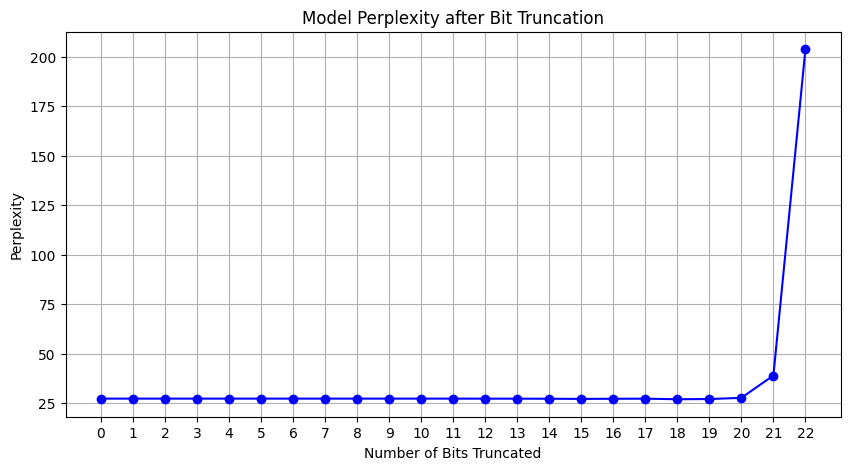

In [28]:
import matplotlib.pyplot as plt

bit_truncation_levels = range(0, 23)
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(list(bit_truncation_levels), ppl_results, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Bits Truncated')
plt.ylabel('Perplexity')
plt.xticks(list(bit_truncation_levels)) 
plt.grid(True)
plt.show()

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2Tokenizer, OPTForCausalLM
from datasets import load_dataset

def calculate_perplexity(model, tokenizer, stride=512):
    test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    max_length = model.config.max_position_embeddings  
    encodings = tokenizer("\n\n".join(test["text"]), return_tensors="pt", padding=True, truncation=True, max_length=max_length)

    nlls = []
    model.eval()
    with torch.no_grad():
        prev_end_loc = 0
        for begin_loc in range(0, encodings.input_ids.size(1), stride):
            end_loc = min(begin_loc + max_length, encodings.input_ids.size(1))
            trg_len = end_loc - prev_end_loc
            input_ids = encodings.input_ids[:, begin_loc:end_loc].to(model.device)
            target_ids = input_ids.clone()
            target_ids[:, :-trg_len] = -100

            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss
            nlls.append(neg_log_likelihood)

            prev_end_loc = end_loc 

    return torch.exp(torch.stack(nlls).mean()).item()

device = "cpu"
model_id = "facebook/opt-125m"
model_name = "facebook_opt-125m"
model = OPTForCausalLM.from_pretrained(model_id)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
model.eval()
model.to(device)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

stride = 512

perplexity = calculate_perplexity(model, tokenizer)
print(f"Perplexity: {perplexity}")


Perplexity: 32.73220443725586


In [7]:
import os
ppl_results = []
save_directory = "truncated_models"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
for num_bits_to_truncate in range(0, 23):
    model = AutoModelForCausalLM.from_pretrained(model_id)
    model.to(device)
    truncate_model_parameters(model, num_bits_to_truncate)
    # model_path = os.path.join(save_directory, f"opt-125m_truncated_{num_bits_to_truncate}_bits")
    # model.save_pretrained(model_path)
    ppl = calculate_perplexity(model, tokenizer)
    print(f"Perplexity after truncating {num_bits_to_truncate} bits: {ppl}")
    ppl_results.append(ppl) 

Perplexity after truncating 0 bits: 32.73220443725586
Perplexity after truncating 1 bits: 32.73220443725586
Perplexity after truncating 2 bits: 32.73220443725586
Perplexity after truncating 3 bits: 32.73220443725586
Perplexity after truncating 4 bits: 32.73220443725586
Perplexity after truncating 5 bits: 32.73220443725586
Perplexity after truncating 6 bits: 32.73220443725586
Perplexity after truncating 7 bits: 32.73220443725586
Perplexity after truncating 8 bits: 32.73220443725586
Perplexity after truncating 9 bits: 32.73220443725586
Perplexity after truncating 10 bits: 32.73220443725586
Perplexity after truncating 11 bits: 32.73220443725586
Perplexity after truncating 12 bits: 32.73220443725586
Perplexity after truncating 13 bits: 32.73220443725586
Perplexity after truncating 14 bits: 32.7294807434082
Perplexity after truncating 15 bits: 32.73122787475586
Perplexity after truncating 16 bits: 32.72924041748047
Perplexity after truncating 17 bits: 32.81825637817383
Perplexity after trun

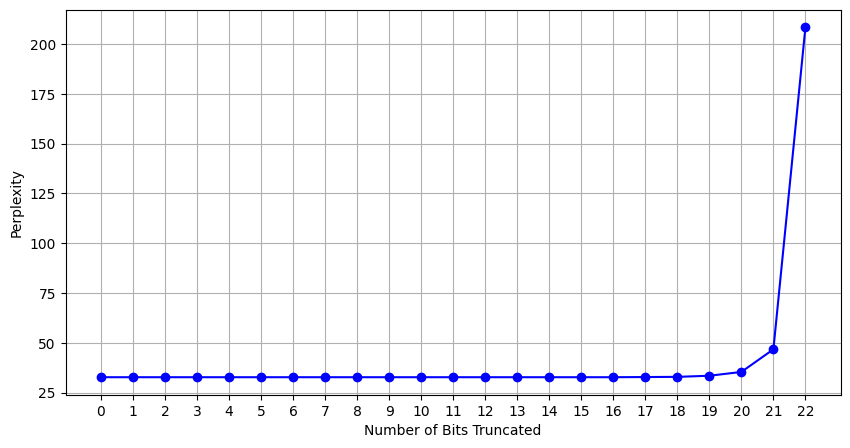

In [15]:
import matplotlib.pyplot as plt

bit_truncation_levels = range(0, 23)
plt.figure(figsize=(10, 5))
plt.plot(list(bit_truncation_levels), ppl_results, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Bits Truncated')
plt.ylabel('Perplexity')
plt.xticks(list(bit_truncation_levels))
plt.grid(True)
plt.show()


In [1]:
! lm_eval --model hf \
    --model_args pretrained=facebook/opt-125m,dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'facebook/opt-125m', 'dtype': 'float32'}
I0000 00:00:1716993427.773852    4718 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswa

In [8]:
! lm_eval --model hf \
    --model_args pretrained="{save_directory}/{model_name}/model_truncated_22_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/facebook_opt-125m/model_truncated_22_bits', 'dtype': 'float32'}
I0000 00:00:1717085070.278328    7658 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building 

In [10]:
! lm_eval --model hf \
    --model_args pretrained="{save_directory}/{model_name}/model_truncated_21_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/facebook_opt-125m/model_truncated_21_bits', 'dtype': 'float32'}
I0000 00:00:1717088719.074073   21579 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building 

In [17]:
! lm_eval --model hf \
    --model_args pretrained="{save_directory}/{model_name}/model_truncated_20_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/facebook_opt-125m/model_truncated_20_bits', 'dtype': 'float32'}
I0000 00:00:1717116349.986722  129597 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building 

In [ ]:
! lm_eval --model hf \
    --model_args pretrained="truncated_models/facebook_opt-125m/model_truncated_19_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/facebook_opt-125m/model_truncated_19_bits', 'dtype': 'float32'}
I0000 00:00:1717123485.084160  161440 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building 

In [ ]:
! lm_eval --model hf \
    --model_args pretrained="truncated_models/facebook_opt-125m/model_truncated_18_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/facebook_opt-125m/model_truncated_18_bits', 'dtype': 'float32'}
I0000 00:00:1717125660.163465  172490 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building 

In [ ]:
! lm_eval --model hf \
    --model_args pretrained="truncated_models/facebook_opt-125m/model_truncated_17_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/facebook_opt-125m/model_truncated_17_bits', 'dtype': 'float32'}
I0000 00:00:1717157580.816334    5903 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building 

In [10]:
! lm_eval --model hf \
    --model_args pretrained="truncated_models/openai-community_gpt2_0_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/openai-community_gpt2_0_bits', 'dtype': 'float32'}
I0000 00:00:1717161060.674006   22116 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building contexts for 

In [11]:
! lm_eval --model hf \
    --model_args pretrained="truncated_models/openai-community_gpt2_17_bits",dtype=float32 \
    --tasks hellaswag \
    --device cpu \
    --batch_size "auto"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
INFO:lm-eval:Verbosity set to INFO
INFO:lm-eval:Selected Tasks: ['hellaswag']
INFO:lm-eval:Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
INFO:lm-eval:Initializing hf model, with arguments: {'pretrained': 'truncated_models/openai-community_gpt2_17_bits', 'dtype': 'float32'}
I0000 00:00:1717161419.467594   23213 cpu_client.cc:370] TfrtCpuClient created.
INFO:lm-eval:Using device 'cpu'
/opt/conda/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for hellaswag contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hellaswag
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
INFO:lm-eval:Building contexts for

In [2]:
import sys
import torch
import os
import traceback
from collections import Counter, defaultdict
from google.cloud import storage
from transformers import AutoModel
from pathlib import Path
from tqdm import tqdm
from transformers import OPTForCausalLM

def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/"
    blobs = bucket.list_blobs(prefix=prefix)
    
    Path(local_path).mkdir(parents=True, exist_ok=True)
    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path):
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")

def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path

def get_shared_storage_tensor_dict(model):
    # finding the layers that shareing memory
    try:
        same_storage_dict = dict()
        for layer_name in model:
            if layer_name in same_storage_dict:
                continue
            layer = model[layer_name]
            for layer_name_check in model:
                if layer_name == layer_name_check:
                    continue
                layer_check = model[layer_name_check]
                if layer.storage().data_ptr() == layer_check.storage().data_ptr():
                    same_storage_dict[layer_name_check] = layer_name
                    if not torch.equal(layer, layer_check):
                        print("not torch.equal(layer, layer_check)")
                        sys.exit()
        return same_storage_dict
    except Exception as e:
        # Code that runs if an exception of ExceptionType occurs
        print(f"An error occurred: get_shared_storage_tensor_dict")
        traceback.print_exc()
        sys.exit()

model_name = 'facebook_opt-125m'
bucket_name = 'downloaded_llms'
model, _ = load_model_from_path(model_name, bucket_name)
model.eval()

shared_storage_dict = get_shared_storage_tensor_dict(model)
print("same_storage_dict:")
for key, value in shared_storage_dict.items():
    print(f"key: {key}, value: {value}")


An error occurred: get_shared_storage_tensor_dict


Traceback (most recent call last):
  File "/var/tmp/ipykernel_16842/180096373.py", line 35, in get_shared_storage_tensor_dict
    for layer_name in model:
TypeError: 'OPTModel' object is not iterable


AttributeError: 'tuple' object has no attribute 'tb_frame'